<a href="https://colab.research.google.com/github/rbatralab/google-colab/blob/main/3_run_dlpfc_sc_cellfie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Script to generate preliminary results for Bright Focus funding - running sccellfie on anndata

In [2]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# install libraries
!pip install sccellfie
!pip install scanpy
!pip install scikit-misc

In [3]:
# libraries needed
import sccellfie # for metabolic estimation
import scanpy as sc # for single cell analysis

In [4]:
# Load the dataset
adata = sc.read(filename="/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis/Prefrontal_cortex_subset_ast_exc.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 48220 × 33538
    obs: 'projid', 'cell_type_high_resolution', 'major_cell_type'
    layers: 'counts', 'data'

### Preprocessing: Filter cells and genes

To address the numerical stability issues and prepare the data for downstream analysis, we'll perform basic filtering:

1.  **Filter cells:** Remove cells with too few unique genes expressed (e.g., less than 200). Very sparse cells often indicate low-quality data or empty droplets.
2.  **Filter genes:** Remove genes that are expressed in too few cells (e.g., less than 3 cells). These genes are often technical noise or uninformative.

In [6]:
# Check if adata.X is None and assign data from 'data' layer first, then 'counts' if 'data' is not available.
if adata.X is None:
    if 'data' in adata.layers:
        adata.X = adata.layers['data']
    elif 'counts' in adata.layers:
        adata.raw.X = adata.layers['counts']

print(f"Initial number of cells: {adata.n_obs}")
print(f"Initial number of genes: {adata.n_vars}")

# Filter cells based on number of genes expressed
sc.pp.filter_cells(adata, min_genes=200)

# Filter genes based on number of cells they are expressed in
sc.pp.filter_genes(adata, min_cells=3)

print(f"Number of cells after filtering: {adata.n_obs}")
print(f"Number of genes after filtering: {adata.n_vars}")

Initial number of cells: 48220
Initial number of genes: 33538
Number of cells after filtering: 48220
Number of genes after filtering: 29240


In [7]:
adata.obs.shape

(48220, 4)

In [8]:
# Run one-command scCellFie pipeline

# Check if adata.X is None and assign data from 'data' layer first, then 'counts' if 'data' is not available.
if adata.X is None:
    if 'counts' in adata.layers:
        adata.raw.X = adata.layers['counts']
    elif 'data' in adata.layers:
        adata.X = adata.layers['data']

results = sccellfie.run_sccellfie_pipeline(adata,
                                           organism='human',
                                           sccellfie_data_folder=None,
                                           n_counts_col='n_counts',
                                           process_by_group=False,
                                           groupby=None,
                                           neighbors_key='neighbors',
                                           n_neighbors=10,
                                           batch_key=None,
                                           threshold_key='sccellfie_threshold',
                                           smooth_cells=True,
                                           alpha=0.33,
                                           chunk_size=5000,
                                           disable_pbar=False,
                                           save_folder=None,
                                           save_filename=None
                                          )


==== scCellFie Pipeline: Initializing ====
Loading scCellFie database for organism: human

==== scCellFie Pipeline: Processing entire dataset ====

---- scCellFie Step: Preprocessing data ----


/usr/local/lib/python3.12/dist-packages/sccellfie/preprocessing/adata_utils.py:177: UserWarning: n_counts not found in adata.obs. Calculating total counts.
  warnings.warn(f"{n_counts_key} not found in adata.obs. Calculating total counts.", UserWarning)
/usr/local/lib/python3.12/dist-packages/sccellfie/preprocessing/adata_utils.py:198: UserWarning: Normalizing data.
  warnings.warn("Normalizing data.", UserWarning)



---- scCellFie Step: Computing neighbors ----


/usr/local/lib/python3.12/dist-packages/sccellfie/sccellfie_pipeline.py:430: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(bdata, n_top_genes=2000, flavor='seurat_v3', batch_key=batch_key)



---- scCellFie Step: Preparing inputs ----
Gene names corrected to match database: 22
Shape of new adata object: (48220, 909)
Number of GPRs: 778
Shape of tasks by genes: (218, 909)
Shape of reactions by genes: (778, 909)
Shape of tasks by reactions: (218, 778)

---- scCellFie Step: Smoothing gene expression ----


Smoothing Expression: 100%|██████████| 10/10 [00:04<00:00,  2.30it/s]
/usr/local/lib/python3.12/dist-packages/sccellfie/expression/smoothing.py:188: ImplicitModificationWarning: Setting element `.layers['smoothed_X']` of view, initializing view as actual.
  adata.layers[key_added] = smoothed_matrix



---- scCellFie Step: Computing gene scores ----

---- scCellFie Step: Computing reaction activity ----


Cell Rxn Activities: 100%|██████████| 48220/48220 [03:58<00:00, 201.95it/s]



---- scCellFie Step: Computing metabolic task activity ----
Removed 1 metabolic tasks with zeros across all cells.

==== scCellFie Pipeline: Processing completed successfully ====


In [10]:
# Save adata objects containing single-cell/spatial predictions
sccellfie.io.save_adata(adata=results['adata'],
                        output_directory="/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis/",
                        filename='prefrontal_cortext_subset_sccellfie_results'
                        )

/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis//prefrontal_cortext_subset_sccellfie_results.h5ad was correctly saved
/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis//prefrontal_cortext_subset_sccellfie_results_reactions.h5ad was correctly saved
/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis//prefrontal_cortext_subset_sccellfie_results_metabolic_tasks.h5ad was correctly saved


In [11]:
# Summarize results in a cell-group level for the Metabolic Task Visualizer
cell_group = 'cell_type_high_resolution'
report = sccellfie.reports.generate_report_from_adata(results['adata'].metabolic_tasks,
                                                      group_by=cell_group,
                                                      tissue_col='condition',
                                                      feature_name='metabolic_task'
                                                      )

# Export files to a specific folder.
sccellfie.io.save_result_summary(results_dict=report, output_directory="/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis/")

# Melted.csv and Min_max.csv are input files for the Metabolic Task Visualizer

Processing tissues: 100%|██████████| 1/1 [00:00<00:00,  1.45it/s]


Results saved to /content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis/


In [12]:
import numpy as np
mrks = sccellfie.external.quick_markers(results['adata'].metabolic_tasks,
                                        cluster_key=cell_group,
                                        n_markers=20,
                                        express_cut=5*np.log(2))

/usr/local/lib/python3.12/dist-packages/sccellfie/external/tf_idf.py:71: RuntimeWarning: divide by zero encountered in divide
  idf = np.log(len(clusters) / n_tot)
/usr/local/lib/python3.12/dist-packages/sccellfie/external/tf_idf.py:72: RuntimeWarning: invalid value encountered in multiply
  tf_idf = tf * idf


In [13]:
mrks.head()

,gene,cluster,tf,idf,tf_idf,gene_frequency_outside_cluster,gene_frequency_global,second_best_tf,second_best_cluster,pval,qval
0,Conversion of glutamate to glutamine,Ast DPP10,0.553099,1.311671,0.725484,0.250647,0.269370,0.553099,Ast DPP10,3.115273e-251,1.014021e-248
1,Phenylalanine to phenylacetaldehyde,Ast DPP10,0.139698,3.732540,0.521430,0.016293,0.023932,0.055232,Ast GRM3,1.456384e-208,3.160352e-206
2,Pyridoxal-phosphate synthesis,Ast DPP10,0.166499,2.346895,0.390756,0.090991,0.095666,0.123763,Ast GRM3,4.212388e-36,2.886594e-34
3,Biosynthesis of Tn_antigen (Glycoprotein N-ace...,Ast DPP10,0.208040,1.708321,0.355400,0.179396,0.181170,0.334875,Exc L4-5 RORB IL1RAPL2,5.909288e-05,9.051639e-04
4,Presence of the thioredoxin system through the...,Ast DPP10,0.063317,3.530059,0.223511,0.027059,0.029303,0.063317,Ast DPP10,1.053132e-23,4.897066e-22


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


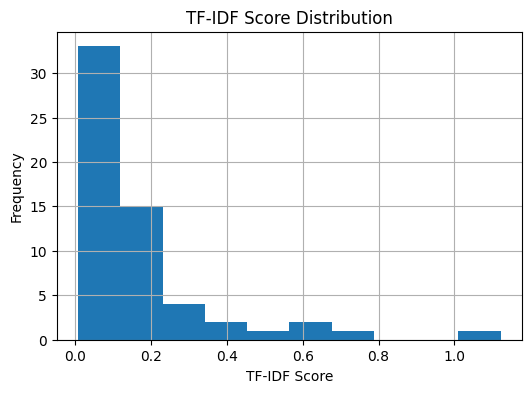

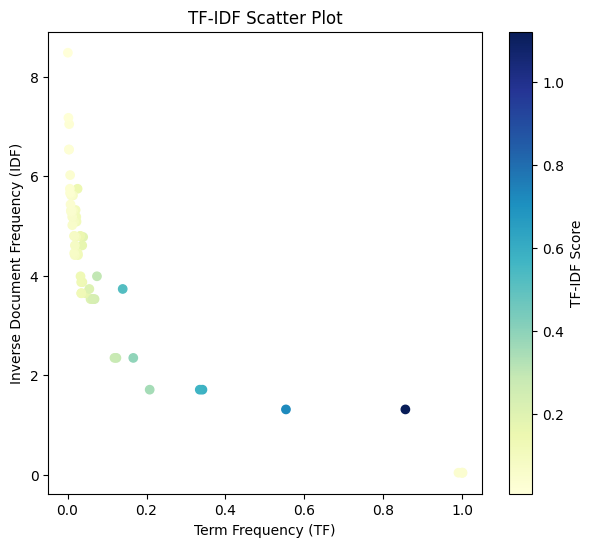

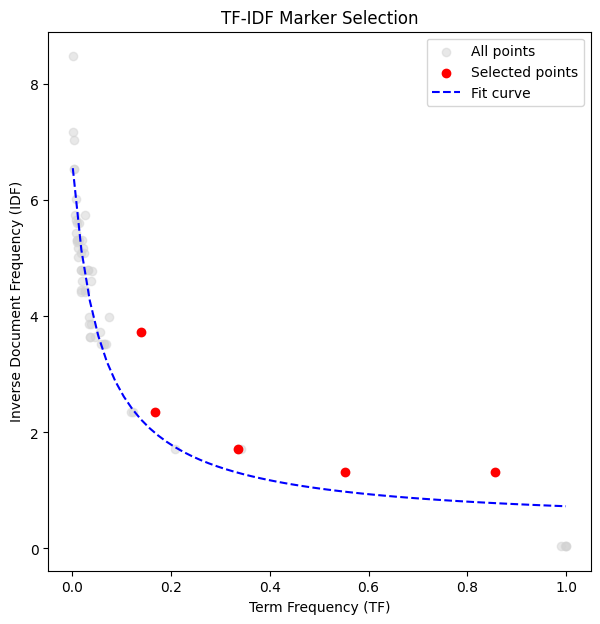

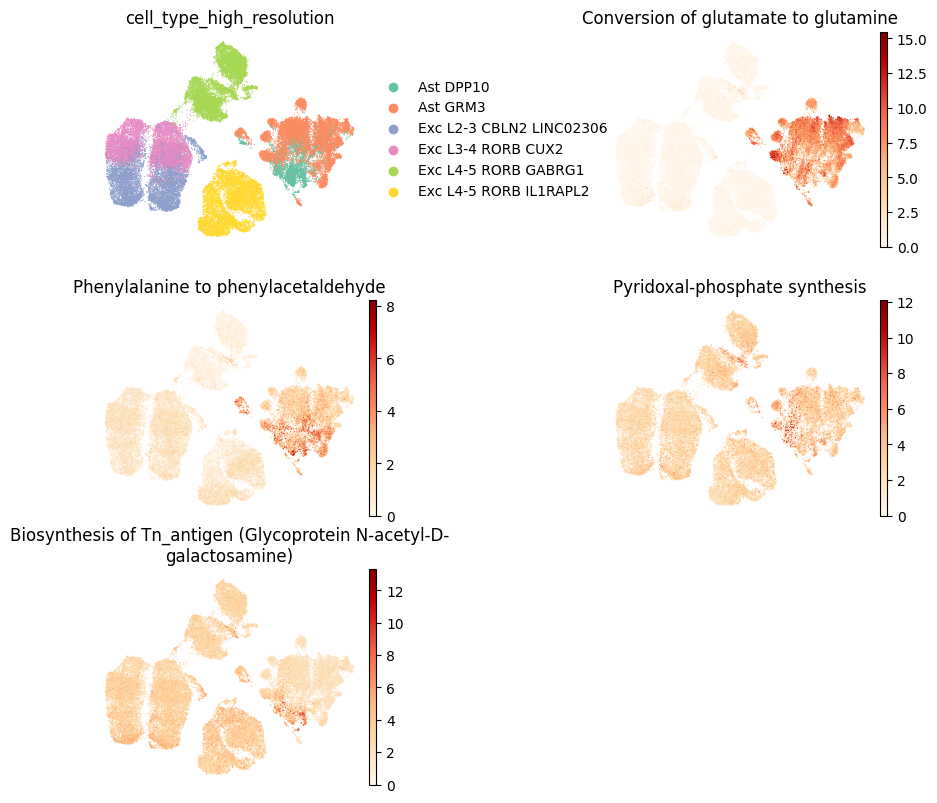

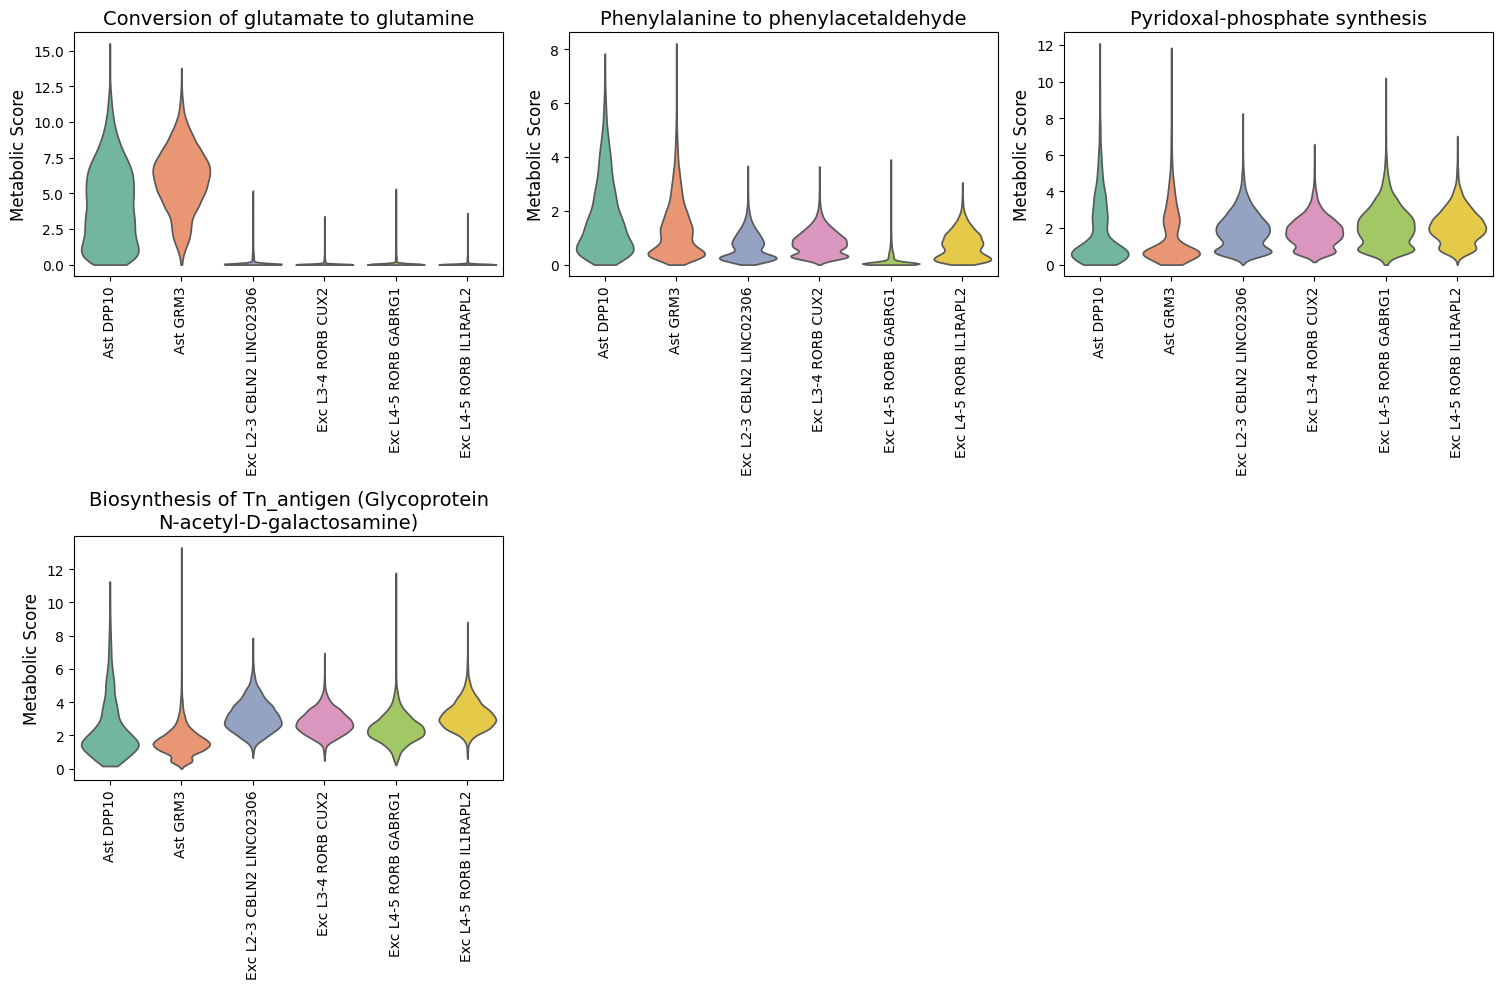

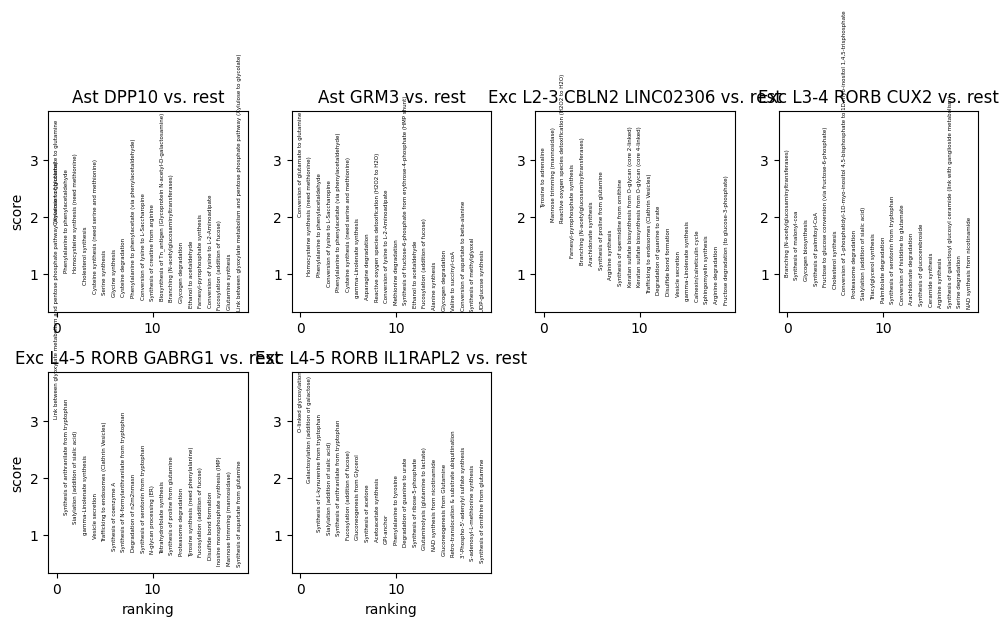

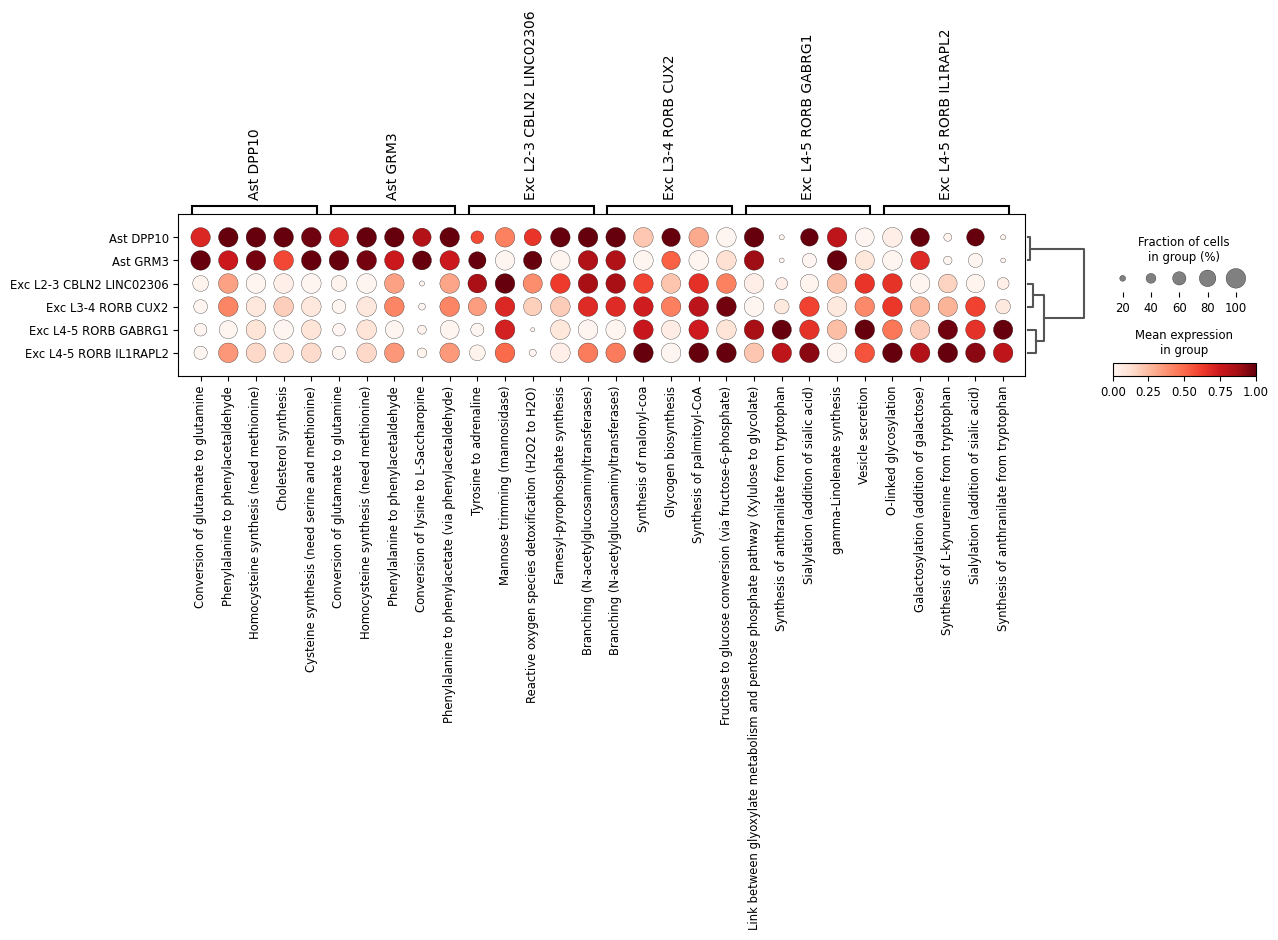

In [14]:
import matplotlib.pyplot as plt
import textwrap
import scanpy as sc
import glasbey
import numpy as np # Ensure numpy is imported if used later in the cell

collected_figures = [] # Initialize a list to store all figure objects

# We use glasbey to expand the palette into a larger number of colors
# This is useful when we have many cell types
palette = glasbey.extend_palette('Set2',
                                 palette_size=max([10, results['adata'].metabolic_tasks.obs[cell_group].unique().shape[0]]))

# --- Plot 1: TF-IDF Histogram ---
plt.figure(figsize=(6,4))
mrks['tf_idf'].hist()
plt.title('TF-IDF Score Distribution')
plt.xlabel('TF-IDF Score')
plt.ylabel('Frequency')
collected_figures.append(plt.gcf())

# --- Plot 2: TF-IDF Scatter (original values) ---
plt.figure(figsize=(7, 6))
scatter = plt.scatter(mrks['tf'], mrks['idf'], c=mrks['tf_idf'], cmap='YlGnBu')
plt.colorbar(scatter, label='TF-IDF Score')
plt.xlabel('Term Frequency (TF)')
plt.ylabel('Inverse Document Frequency (IDF)')
plt.title('TF-IDF Scatter Plot')
collected_figures.append(plt.gcf())

x_col = 'tf'
y_col = 'idf'
df = mrks
tfidf_threshold = 0.3
tf_ratio = 1.2

# --- Plot 3: TF-IDF Selection Visualization ---
fig_tfidf_selection = plt.figure(figsize=(7, 7))
# Plot all points
plt.scatter(df[x_col], df[y_col], alpha=0.5, c='lightgray', label='All points')
# Plot selected points
filtered_mrks, curve = sccellfie.external.filter_tfidf_markers(df, tf_col=x_col, idf_col=y_col, tfidf_threshold=tfidf_threshold, tf_ratio=tf_ratio)
plt.scatter(filtered_mrks[x_col], filtered_mrks[y_col], c='red', label='Selected points')
plt.plot(*curve, label='Fit curve', color='blue', linestyle='--')
plt.xlabel('Term Frequency (TF)')
plt.ylabel('Inverse Document Frequency (IDF)')
plt.title('TF-IDF Marker Selection')
plt.legend()
collected_figures.append(fig_tfidf_selection)

tf_idf_mrks = filtered_mrks['gene'].unique().tolist()
# print(f"Number of selected TF-IDF markers: {len(tf_idf_mrks)}") # Optional: to see the count

# Adjust default figure params for scanpy plots if needed, or set individually
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams['font.size'] = 10

# --- Plot 4: UMAP Embeddings ---
# sc.pl.embedding returns an Axes object or array of Axes. We need to get its figure.
axes_embedding = sc.pl.embedding(results['adata'].metabolic_tasks,
                                color=[cell_group] + tf_idf_mrks,
                                ncols=2,
                                palette=palette,
                                frameon=False,
                                basis='X_umap',
                                wspace=0.7,
                                title=["\n".join(textwrap.wrap(t, width=60)) for t in [cell_group] + tf_idf_mrks],
                                cmap='OrRd',
                                show=False # Crucial: prevent display and automatic closing
                               )
# Get the figure object from the Axes returned by sc.pl.embedding
# If it's a list of axes (e.g., from ncols > 1), take the figure from the first axes.
# Otherwise, it's a single axes object.
if isinstance(axes_embedding, list):
    # The figure object is typically accessible via any of the axes in the list
    collected_figures.append(axes_embedding[0].figure)
else:
    collected_figures.append(axes_embedding.figure)

# --- Plot 5: Multi-Violin Plots ---
fig_violin, _ = sccellfie.plotting.create_multi_violin_plots(results['adata'].metabolic_tasks,
                                                         features=tf_idf_mrks,
                                                         groupby=cell_group,
                                                         stripplot=False,
                                                         n_cols=3,
                                                         ylabel='Metabolic Score'
                                                        )
collected_figures.append(fig_violin)

method = 'logreg'
sc.tl.rank_genes_groups(results['adata'].metabolic_tasks, cell_group, method=method,
                        use_raw=False, key_added = method)

# --- Plot 6: Rank Genes Groups (e.g., heatmap or strip plot) ---
# sc.pl.rank_genes_groups returns a list of axes, get the figure from the first axis
axes_rank_genes = sc.pl.rank_genes_groups(results['adata'].metabolic_tasks, n_genes=20, sharey=True, key=method, fontsize=4, show=False)
if isinstance(axes_rank_genes, list) and axes_rank_genes:
    collected_figures.append(axes_rank_genes[0].figure)
else:
    # Fallback in case it returns a single axes or an unexpected type (though less likely)
    collected_figures.append(plt.gcf()) # Append current figure if previous didn't return a list

# --- Plot 7: Rank Genes Groups Dotplot ---
# sc.pl.rank_genes_groups_dotplot returns a dictionary of matplotlib objects, get the figure from the main plot axis
fig_dotplot_dict = sc.pl.rank_genes_groups_dotplot(results['adata'].metabolic_tasks, n_genes=5, groupby=cell_group,
                                key=method, use_raw=False, standard_scale='var', show=False
                               )
if 'mainplot_ax' in fig_dotplot_dict:
    collected_figures.append(fig_dotplot_dict['mainplot_ax'].figure)
else:
    collected_figures.append(plt.gcf()) # Fallback if 'mainplot_ax' is not found

# Optional: display the number of collected figures for verification
# print(f"Total figures collected: {len(collected_figures)}")

In [16]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt # Ensure plt is imported here

# Define the output PDF filename
pdf_filename = "/content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis/prefrontal_cortex_subset_metabolic_task_plots.pdf"

# Use the collected_figures list from the previous cell
# It's crucial that the plotting cell (0Nrn4s5t4r2X) is run BEFORE this cell

with PdfPages(pdf_filename) as pdf:
    if 'collected_figures' in globals() and collected_figures:
        for fig in collected_figures:
            if isinstance(fig, plt.Figure): # Ensure it's actually a Figure object
                fig.tight_layout() # Add this line to prevent clipping
                pdf.savefig(fig)
            plt.close(fig) # Close the figure to free up memory after saving
    else:
        print("No figures were collected. Please ensure the plotting cell (0Nrn4s5t4r2X) was run and figures were appended to 'collected_figures'.")

print(f"All plots saved to {pdf_filename}")

/tmp/ipykernel_2281/3591081710.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout() # Add this line to prevent clipping


All plots saved to /content/drive/MyDrive/Grants/2026-09-BrightFocus/prelim-analysis/prefrontal_cortex_subset_metabolic_task_plots.pdf


In [18]:
results['adata'].metabolic_tasks

AnnData object with n_obs × n_vars = 48220 × 217
    obs: 'projid', 'cell_type_high_resolution', 'major_cell_type', 'n_genes', 'total_counts'
    uns: 'normalization', 'neighbors', 'umap', 'cell_type_high_resolution_colors', 'logreg', 'dendrogram_cell_type_high_resolution'
    obsm: 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'
    layers: None (.X)